Loading standard libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Loading dataset

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()

faces = olivetti.images
y = olivetti.target

Display shape of dataset

In [ ]:
print("Dataset shape: ",faces.shape)
print("Target shape: ",y.shape)

Dataset shape:  (400, 64, 64)
Target shape:  (400,)


In [ ]:
print("Unique classes:",np.unique(y))

Unique classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39]


In [ ]:
# Number of unique values of target
print("Number of unique classes:",len(np.unique(y)))

Number of unique classes: 40


Displaying images

In [ ]:
def plot_images(images, labels=None, n_row=3, n_col=10, title=None):
    plt.figure(figsize=(2 * n_col, 2.5 * n_row))
    for i in range(n_row * n_col):
        if i >= len(images):
            break
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape(64, 64), cmap='gray') # For image shape = (64,64)
        if labels is not None:
            plt.title(f"Person {labels[i]}")
        plt.xticks([])
        plt.yticks([])
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()

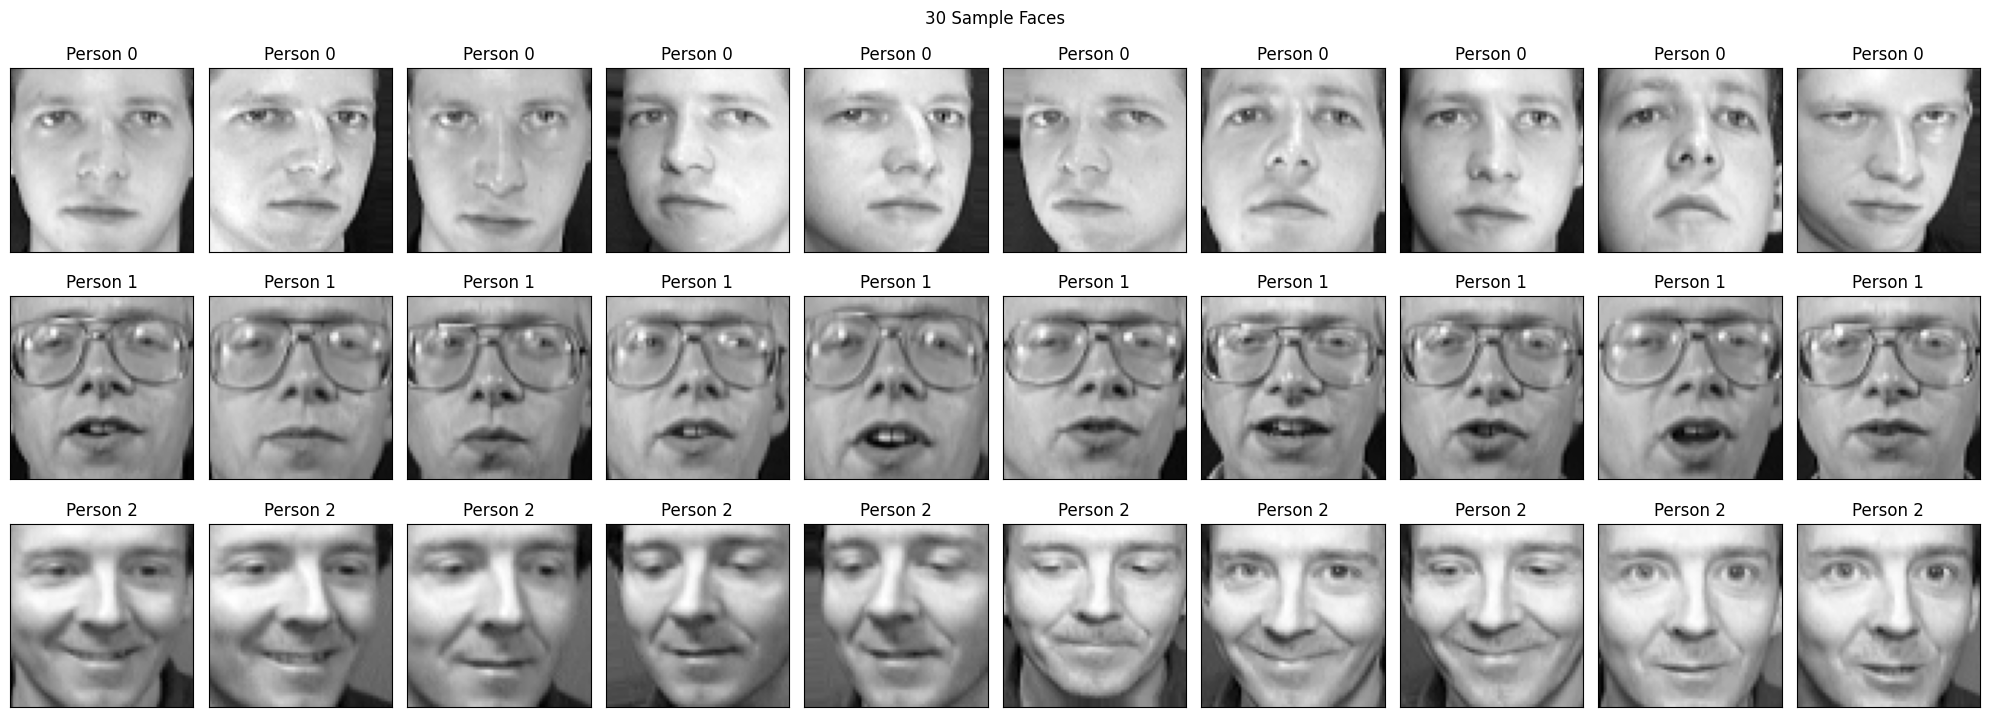

In [ ]:
# Plot first 30 faces
plot_images(faces[:30], y[:30], title="30 Sample Faces")

# Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_dummy, y_train, y_dummy = train_test_split(faces, y, test_size=0.3, random_state=42, stratify=y)
X_test, X_val, y_test, y_val = train_test_split(X_dummy, y_dummy, test_size=0.33, random_state=42, stratify=y_dummy)

In [ ]:
X_train.shape

(280, 64, 64)

Flatten the images from 64x64 to 4096

In [ ]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_val = X_val.reshape(X_val.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

In [ ]:
print("Design matrix shape (N x 4096):",X_train.shape)

Design matrix shape (N x 4096): (280, 4096)


X_train is the design matrix

Check the shape of train, test and validation datasets

In [ ]:
# Check if train, test and validation datasets are split class wise
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))
print(np.unique(y_val, return_counts=True))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39]), array([7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39]), array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))


We can check the 7-2-1 distribution

# Mean image of train, test and validation sets

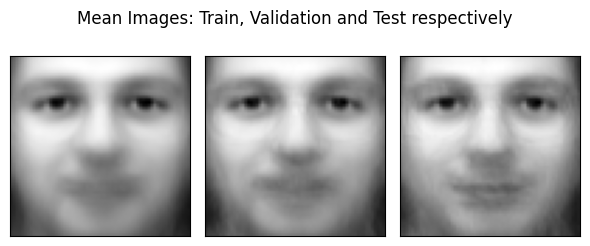

In [ ]:
mean_train = np.mean(X_train, axis=0)
mean_test = np.mean(X_test, axis=0)
mean_val = np.mean(X_val, axis=0)

plot_images([mean_train, mean_test, mean_val],n_row=1,n_col=3,title="Mean Images: Train, Validation and Test respectively")

# Implementing PCA from Scratch

In [ ]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        cov_matrix = np.cov(X_centered, rowvar=False) # Covariance matrix
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Sort eigenvalues and eigenvectors
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        self.components = eigenvectors[:, :self.n_components] # Select top n components

    def transform(self, X):
        # Project data onto principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def inverse_transform(self, X_reduced):
        # Reconstruct original data from principal components
        return np.dot(X_reduced, self.components.T) + self.mean


In [ ]:
# Initialize and fit PCA
pca_scratch = PCAFromScratch(n_components=2)
pca_scratch.fit(X_train)

# Cross validation

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
k_values = [5, 10, 15, 20, 25, 30, 40, 50, 75, 100, 150, 200, 279]

In [ ]:
accuracy = []

In [ ]:
for k in k_values:
  pca_cv = PCAFromScratch(n_components=k)
  pca_cv.fit(X_train)
  X_train_reduced = pca_cv.transform(X_train)
  X_val_reduced = pca_cv.transform(X_val)

  knn = KNeighborsClassifier(n_neighbors=1)
  knn.fit(X_train_reduced, y_train)
  y_pred = knn.predict(X_val_reduced)

  accuracy.append(accuracy_score(y_val, y_pred))

In [ ]:
for i in range(len(k_values)):
  print(f"Accuracy for k={k_values[i]}: {accuracy[i]}")

Accuracy for k=5: 0.75
Accuracy for k=10: 0.95
Accuracy for k=15: 0.975
Accuracy for k=20: 0.975
Accuracy for k=25: 0.975
Accuracy for k=30: 0.975
Accuracy for k=40: 0.975
Accuracy for k=50: 0.975
Accuracy for k=75: 0.975
Accuracy for k=100: 0.95
Accuracy for k=150: 0.95
Accuracy for k=200: 0.95
Accuracy for k=279: 0.95


In [ ]:
max(accuracy)

0.975

# Plotting Accuracy vs k graph

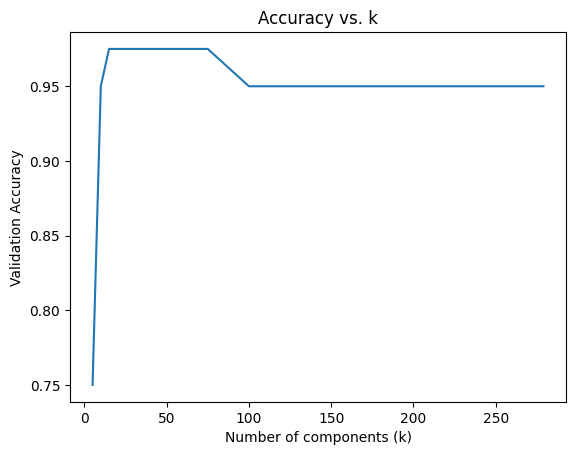

In [ ]:
# Plot accuracy as a function of k
plt.plot(k_values, accuracy)
plt.xlabel('Number of components (k)')
plt.ylabel('Validation Accuracy')
plt.title('Accuracy vs. k')
plt.show()

In [ ]:
# get lowest value of k with maximum accuracy
max_accuracy = max(accuracy)
max_index = accuracy.index(max_accuracy)
print(k_values[max_index])

15


k = 15 for max accuracy

# Visualizing the eigenfaces

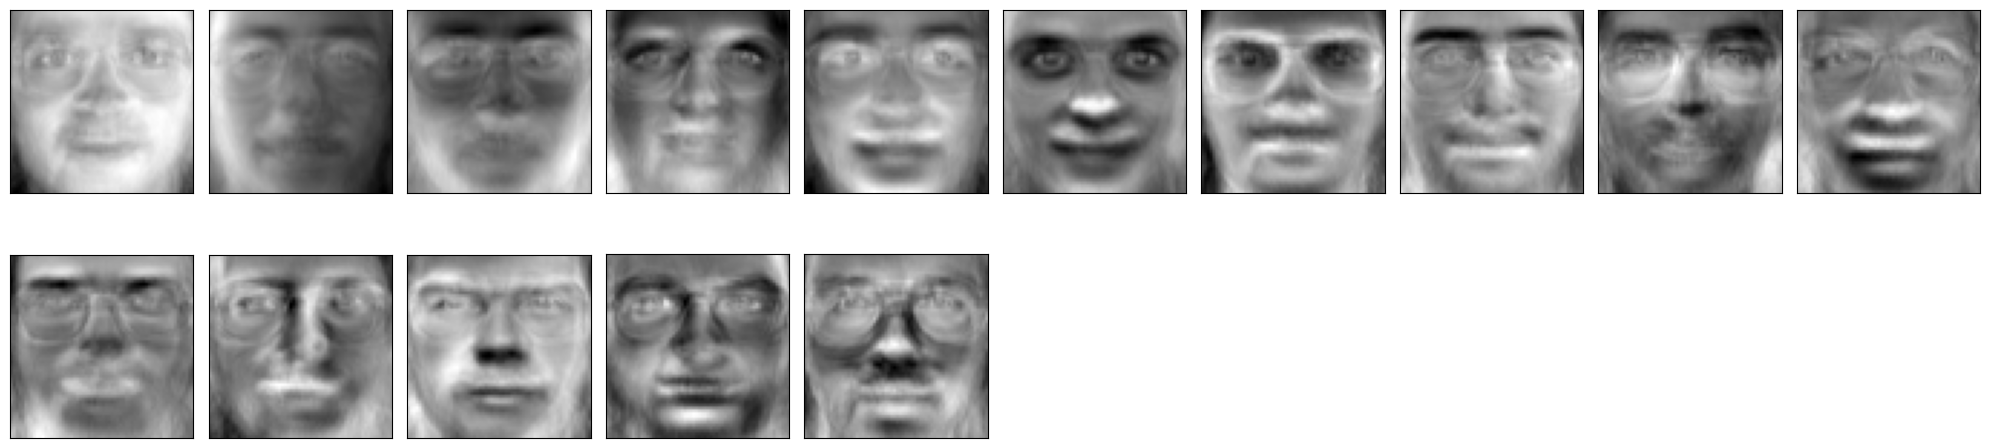

Text(0.5, 0.98, 'Top 15 Eigenfaces')

<Figure size 640x480 with 0 Axes>

In [ ]:
# Visualize the k eigen vectors as eigenfaces for the chosen value of k.
pca_eigen = PCAFromScratch(n_components=k_values[max_index])
pca_eigen.fit(X_train)
plot_images(pca_eigen.components.T[:k_values[max_index]])
plt.suptitle(f"Top {k_values[max_index]} Eigenfaces")

# Checking accuracy on test set

In [ ]:
pca_test = PCAFromScratch(n_components=k_values[max_index])
pca_test.fit(X_train)
X_train_reduced = pca_test.transform(X_train)
X_test_reduced = pca_test.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_reduced, y_train)
y_pred = knn.predict(X_test_reduced)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.8875


# Compare with sklearn implementation

In [ ]:
from sklearn.decomposition import PCA

# Initialize and fit PCA using scikit-learn
pca_sklearn = PCA(n_components=k_values[max_index])
X_pca_sklearn = pca_sklearn.fit_transform(X_train)

In [ ]:
X_train_sklearn_reduced = pca_sklearn.transform(X_train)
X_test_sklearn_reduced = pca_sklearn.transform(X_test)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_sklearn_reduced, y_train)
y_pred_sklearn = knn.predict(X_test_sklearn_reduced)

In [ ]:
print(accuracy_score(y_test, y_pred_sklearn))

0.8875


Comparing both accuracies:

In [ ]:
print(f"Scratch PCA Test Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Sklearn PCA Test Accuracy: {accuracy_score(y_test, y_pred_sklearn):.3f}")


Scratch PCA Test Accuracy: 0.887
Sklearn PCA Test Accuracy: 0.887
